# Gatekeeper — `asymptotic-equality-test-plan_revised`

Standalone runner for the **Gatekeeper** step in [`plans/20260404-1746h_asymptotic-equality-test-plan_revised.md`](../plans/20260404-1746h_asymptotic-equality-test-plan_revised.md) (§2, *Gatekeeper — baseline, single type*).

**What it does**

1. Runs `compare_four_methods` from `FromPandemicCode/verify_four_methods_agreement.py` (four-way **mean AggCons per capita** (economy total ÷ `AgentCount`), four-way **mean marginal utility** `E[u'(cLvl_{splurge})]`, TM init-stability diagnostics).
2. Writes the mandatory Markdown report under `history/` with basename `asymptotic-equality-test-plan_revised_Gatekeeper_<YYYYMMDDTHHMM>.md` (UTC, no seconds) and a **`## Step timing`** footer (§2.1).
3. Updates `history/asymptotic-equality-test-plan_revised_progress.md` for the Gatekeeper row (§2.2).
4. Plots a **time series** of cross-sectional **mean marginal utility** for **MC P** and **MC Q**, with **TM P** and **TM Q** as horizontal reference lines (stationary baseline).
5. **Last:** plots **burn-in dynamics** (after TM ergodic draw, each inner ``sim_one_period`` step): cross-sectional means of **mNrm**, **aNrm**, **pLvl**, **cLvl_splurge**, **mean MU**, **employed share**, and **Var(log mNrm)**, **Var(log pLvl)**.

**Execute from repo** (from `Code/HA-Models`):

```bash
cd Code/HA-Models
MPLBACKEND=Agg uv run jupyter nbconvert --to notebook --execute Gatekeeper_Asymptotic_Equality.ipynb --output Gatekeeper_Asymptotic_Equality.ipynb
```

Or open and *Run all* in Jupyter/VS Code.


### Why we use an inner **burn-in** after TM initialization

The transition matrix only has **normalized wealth × employment** `(m,j)` as its Markov state. **`pLvl` is not part of that TM.** MC initialization therefore draws `(m,j)` from the TM ergodic and draws **levels** of `pLvl` from a **separate recipe** (synthetic draw aligned with `u_ergodic` for growth/variance; see BUG-018). That does **not** reproduce the **joint** stationary distribution of the full Monte Carlo: in particular, **`p` is not conditioned on the same `j`** used for wealth. Each `sim_one_period` then **couples** `p` and `j`, so cross-sections **keep adjusting** after the mechanical TM draw.

So the inner burn-in is **not** about “waiting for recessions” (this Gatekeeper path is **base / no recession**). It is about letting the simulated **joint** `(p,m,j)` move **closer** to what simultaneous MC dynamics imply, before `save_state` / `run_experiment`. Deeper discussion: `pLvl_TM_init_ergodic_gap.ipynb`.

In [1]:
import os
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

# Repo root: search up from cwd and from this notebook's directory
_HERE = Path.cwd().resolve()
_CANDIDATES = [_HERE]
for _p in (_HERE, ):
    for _ in range(5):
        _p = _p.parent
        _CANDIDATES.append(_p)
# De-duplicate preserving order
_seen = set()
_CANDIDATES = [c for c in _CANDIDATES if not (c in _seen or _seen.add(c))]
REPO_ROOT = None
for _cand in _CANDIDATES:
    if (_cand / "plans" / "asymptotic-equality-test-plan_revised.md").is_file():
        REPO_ROOT = _cand
        break
if REPO_ROOT is None:
    REPO_ROOT = _HERE.parent.parent
print(f"REPO_ROOT: {REPO_ROOT}")
HISTORY_DIR = REPO_ROOT / "history"
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

_FPC = REPO_ROOT / "Code" / "HA-Models" / "FromPandemicCode"
if not (_FPC / "verify_four_methods_agreement.py").is_file():
    raise FileNotFoundError(f"Expected verify_four_methods_agreement.py under {_FPC}")
os.chdir(_FPC)
if str(_FPC) not in sys.path:
    sys.path.insert(0, str(_FPC))
_HM = _FPC.parent
if str(_HM) not in sys.path:
    sys.path.insert(0, str(_HM))

PLAN_STEM = "asymptotic-equality-test-plan_revised"
STEP_NAME_FILE = "Gatekeeper"
PROGRESS_NAME = "asymptotic-equality-test-plan_revised_progress.md"

print("REPO_ROOT:", REPO_ROOT)
print("FromPandemicCode:", _FPC)


REPO_ROOT: /home/shared/github/llorracc/HAFiscal-Latest
REPO_ROOT: /home/shared/github/llorracc/HAFiscal-Latest
FromPandemicCode: /home/shared/github/llorracc/HAFiscal-Latest/Code/HA-Models/FromPandemicCode


In [2]:
# Small tier: N=1000, mCount=50. Default DualAggFiscalType (no shuffle+norm).
# Set variance_reduction=True only when HARK exposes PermanentIncomeNormalizationMixin
# so AggFiscalModel defines NormalizedDualAggFiscalType (see hafiscal_normalization.py).
# warmup=None → 1/pDeath (≈160 quarters).
# pq_rtol loosened for small-N MC noise on the same-path P vs Q reconstruction.
GATEKEEPER_PARAMS = dict(
    educ="highschool",
    periods=200,
    agents=1_000,
    seed=42,
    m_count=50,
    warmup=None,
    t_start=100,
    use_burnin=True,
    rtol=0.05,
    atol=0.0,
    pq_rtol=0.005,
    diagnose_init=True,
    check_mu=True,
    mu_rtol=0.15,
    check_felicity=False,
    drift_mu_rel=0.25,
    mu_p_points=120,
    record_burnin_trace=True,
    variance_reduction=False,
)

GATEKEEPER_PARAMS


{'educ': 'highschool',
 'periods': 200,
 'agents': 1000,
 'seed': 42,
 'm_count': 50,
 'warmup': None,
 't_start': 100,
 'use_burnin': True,
 'rtol': 0.05,
 'atol': 0.0,
 'pq_rtol': 0.005,
 'diagnose_init': True,
 'check_mu': True,
 'mu_rtol': 0.15,
 'check_felicity': False,
 'drift_mu_rel': 0.25,
 'mu_p_points': 120,
 'record_burnin_trace': True,
 'variance_reduction': False}

In [3]:
from verify_four_methods_agreement import HAS_DUAL, compare_four_methods

if not HAS_DUAL:
    raise RuntimeError("DualAggFiscalType required for Gatekeeper (MC-Q).")

wall_start = datetime.now(timezone.utc)
t0 = time.perf_counter()

out = compare_four_methods(verbose=True, **GATEKEEPER_PARAMS)

wall_end = datetime.now(timezone.utc)
elapsed_s = time.perf_counter() - t0

init_ok = True
if out.get("init_stability"):
    init_ok = bool(out["init_stability"].get("init_looks_stable", True))

overall_pass = bool(out["passed"]) and init_ok
print("\n=== Notebook summary ===")
print("compare_four_methods passed:", out["passed"])
print("init_looks_stable:", init_ok)
print("overall (incl. init):", overall_pass)


EducationGroup:  0 , betaDistr : [0.4827, 0.5674, 0.6521, 0.7368, 0.8215, 0.9062, 0.9909]
EducationGroup:  1 , betaDistr : [0.858, 0.8803, 0.9025, 0.9248, 0.947, 0.9693, 0.9904]
EducationGroup:  2 , betaDistr : [0.9695, 0.9737, 0.9779, 0.9821, 0.9863, 0.9905, 0.9947]
CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]



Single type: highschool, N=1000, T=200, mCount=50, seed=42
Class A reference mean AggCons per capita (**TM-Q**): 14.6130  (legacy avg TM-P & TM-Q = 14.6189, diagnostic)

Method                   mean C / N  |·−TM-Q|/TM-Q   time (s)    ok
----------------------------------------------------------------------
TM P (2D)                   14.6249         0.08%        0.9  diag
TM Q (neutral)              14.6130         0.00%        0.3  True
MC P                        14.7545         0.97%        0.9  True
MC Q (Harmenberg)           14.7624         1.02%        0.9  True

MC timing is one block: save_state, switch to base, shock histories, run_experiment (AggCons and AggCons_Q together); table is per-capita.

|P_MC - Q_MC| / ref (per-capita identity check): 0.0541%
Tolerance: rtol=0.05, atol=0.0 (atol: per-capita level)
Mean mNrm: MC-P = 1.3823   TM-P ergodic = 1.3913   |MC−TM|/TM = 0.64%  ok  (tol rtol_m=0.05)

Mean marginal utility E[u'(cLvl_splurge)] (p-nonlinear: P and Q measures g

In [4]:
import math

def _fmt_duration(seconds: float) -> str:
    s = int(round(seconds))
    m, s = divmod(s, 60)
    h, m = divmod(m, 60)
    if h:
        return f"{h}h {m}m {s}s"
    if m:
        return f"{m}m {s}s"
    return f"{s}s"


def _report_basename_utc() -> str:
    base = wall_start.strftime("%Y%m%dT%H%M")
    name = f"{PLAN_STEM}_{STEP_NAME_FILE}_{base}.md"
    p = HISTORY_DIR / name
    n = 2
    while p.is_file():
        name = f"{PLAN_STEM}_{STEP_NAME_FILE}_{base}_{n}.md"
        p = HISTORY_DIR / name
        n += 1
    return name


report_bn = _report_basename_utc()
report_path = HISTORY_DIR / report_bn

# ---------------------------------------------------------------------------
# Compute all gate results
# ---------------------------------------------------------------------------
ref = out["ref"]
rtol = GATEKEEPER_PARAMS["rtol"]
mu_rtol = GATEKEEPER_PARAMS["mu_rtol"]
pq_rtol = GATEKEEPER_PARAMS["pq_rtol"]

# Class A: per-method AggCons per-capita relative error
class_a_rows = []
for label, val in [("TM-P", out["mean_tm_p"]), ("TM-Q", out["mean_tm_q"]),
                    ("MC-P", out["mean_mc_p"]), ("MC-Q", out["mean_mc_q"])]:
    err = abs(val - ref) / ref
    ok = err <= rtol
    class_a_rows.append((label, val, err, ok))

# Class A: MC P-Q identity
pq_err = out["pq_mc_rel_err"]
pq_ok = pq_err <= pq_rtol or abs(out["mean_mc_p"] - out["mean_mc_q"]) <= max(GATEKEEPER_PARAMS.get("atol", 0), 1e-9)

# Class B: within-measure MU
mu_err_P = out["mu_err_P"]
mu_err_Q = out["mu_err_Q"]
mu_ok_P = mu_err_P <= mu_rtol
mu_ok_Q = mu_err_Q <= mu_rtol

overall_pass_val = bool(out["passed"]) and init_ok

# ---------------------------------------------------------------------------
# Build report
# ---------------------------------------------------------------------------
L = []  # lines
L.append(f"# {PLAN_STEM} — {STEP_NAME_FILE}")
L.append("")
L.append(f"**Generated (UTC):** {wall_end.isoformat()}")
L.append("")
L.append("**Plan:** `plans/20260404-1746h_asymptotic-equality-test-plan_revised.md` (Gatekeeper §2)")
L.append("")
L.append("**Method parity reference:** `plans/method-parity-map.md`")
L.append("")

# --- Overall verdict ---
L.append("## Overall verdict")
L.append("")
L.append(f"**{'PASS' if overall_pass_val else 'FAIL'}**")
L.append("")

gate_summary = []
# Per-method table: each of TM-P, TM-Q, MC-P, MC-Q vs ref = avg(TM-P, TM-Q), rtol.
# This is independent of the tight MC-P vs MC-Q identity check (pq_rtol) below.
agg_vs_tm_ref_ok = all(r[3] for r in class_a_rows)
gate_summary.append(("Class A: AggCons vs TM ref (per method)", "PASS" if agg_vs_tm_ref_ok else "FAIL", f"rtol={rtol}"))
gate_summary.append(("Class A: MC P=Q identity", "PASS" if pq_ok else "FAIL", f"pq_rtol={pq_rtol}"))
gate_summary.append(("Class B: MU, P-measure (TM-P kernel vs MC-P)", "PASS" if mu_ok_P else "FAIL", f"mu_rtol={mu_rtol}, err={100*mu_err_P:.2f}%"))
gate_summary.append(("Class B: MU, Q-measure (TM-Q kernel vs MC-Q)", "PASS" if mu_ok_Q else "FAIL", f"mu_rtol={mu_rtol}, err={100*mu_err_Q:.2f}%"))
gate_summary.append(("Init stability", "PASS" if init_ok else "FAIL", "early-period drift within thresholds"))

L.append("| Gate | Result | Detail |")
L.append("|------|--------|--------|")
for name, result, detail in gate_summary:
    L.append(f"| {name} | **{result}** | {detail} |")
L.append("")
L.append("**Note:** The row *AggCons vs TM ref* matches the Class A table (each method vs "
         "avg(TM-P,TM-Q)). *MC P=Q identity* is separate: MC-P and MC-Q can each be near "
         "that TM midpoint while still differing from each other by more than `pq_rtol`.")
L.append("")
L.append("**Note on pass criterion:** This Gatekeeper runs a single MC seed, so the pass/fail")
L.append("gates above use fixed relative tolerances (rtol, mu_rtol).")
L.append("The multi-type phases (`test_asymptotic_equality_revised.py`) run multiple seeds")
L.append("and use the **3 SE criterion**: TM value within 3 standard errors of the MC")
L.append("cross-seed mean (see plan §1.2). To enable SE-based testing here, extend")
L.append("`compare_four_methods` to multi-seed (listed in plan §7 as open gap).")
L.append("")

# --- Parametrization ---
L.append("## Parametrization")
L.append("")
L.append("```text")
L.append(
    "python verify_four_methods_agreement.py "
    f"--educ {GATEKEEPER_PARAMS['educ']} "
    f"--periods {GATEKEEPER_PARAMS['periods']} "
    f"--agents {GATEKEEPER_PARAMS['agents']} "
    f"--seed {GATEKEEPER_PARAMS['seed']} "
    f"--m-count {GATEKEEPER_PARAMS['m_count']} "
    f"--warmup {GATEKEEPER_PARAMS['warmup']}"
)
L.append("```")
L.append("")

# --- Class A ---
L.append("## Class A: Mean AggCons per capita")
L.append("")
L.append("**Method parity rule (method-parity-map.md):** All four methods (MC-P, MC-Q, TM-P, TM-Q)")
L.append("should agree. AggCons is p-linear; the Harmenberg factorization is exact.")
L.append("")
L.append(f"Reference = avg(TM-P, TM-Q) = {ref:.4f}.  Tolerance: rtol = {rtol} (single-seed fallback).")
L.append("")
L.append("| Method | Value | |err|/ref | Tolerance | Result |")
L.append("|--------|------:|---------:|-----------|--------|")
for label, val, err, ok in class_a_rows:
    L.append(f"| {label} | {val:.4f} | {100*err:.2f}% | {100*rtol:.1f}% | **{'PASS' if ok else 'FAIL'}** |")
L.append("")
L.append(f"MC P vs Q identity: |P-Q|/ref = {100*pq_err:.4f}% (tol={100*pq_rtol:.2f}%) — **{'PASS' if pq_ok else 'FAIL'}**")
L.append("")

# --- Class B: MU ---
L.append("## Class B: Mean marginal utility E[u'(c)]")
L.append("")
L.append("**Method parity rule (method-parity-map.md):** u'(c) is p-nonlinear (k = -CRRA).")
L.append("P and Q measures give **different answers** (~20% different for CRRA=2).")
L.append("Valid comparisons: TM-P kernel vs MC-P, and TM-Q kernel vs MC-Q (within-measure only).")
L.append("**Invalid:** any cross-measure comparison (MC-P vs MC-Q, TM-P vs TM-Q for this quantity).")
L.append("")
L.append(f"Tolerance: mu_rtol = {mu_rtol} ({100*mu_rtol:.1f}%) (single-seed fallback).")
L.append("")
L.append("| Comparison | TM kernel | MC | |TM-MC|/MC | Tolerance | Result |")
L.append("|------------|----------:|---:|---------:|-----------|--------|")
L.append(f"| P-measure | {out['mean_mu_tm_p']:.4e} | {out['mean_mu_mc_p']:.4e} | {100*mu_err_P:.2f}% | {100*mu_rtol:.1f}% | **{'PASS' if mu_ok_P else 'FAIL'}** |")
L.append(f"| Q-measure | {out['mean_mu_tm_q']:.4e} | {out['mean_mu_mc_q']:.4e} | {100*mu_err_Q:.2f}% | {100*mu_rtol:.1f}% | **{'PASS' if mu_ok_Q else 'FAIL'}** |")
L.append("")
L.append(f"(P and Q differ by {abs(out['mean_mu_mc_p']-out['mean_mu_mc_q'])/out['mean_mu_mc_p']*100:.1f}% — expected for k != 1)")
L.append("")

# --- Init stability ---
L.append("## Init stability (early-period drift)")
L.append("")
if out.get("init_stability"):
    st = out["init_stability"]
    L.append(f"- **init_looks_stable:** {st.get('init_looks_stable')} — **{'PASS' if init_ok else 'FAIL'}**")
    L.append(f"- max |Δ mean(mNrm)|/mean_0: {st.get('max_m_drift_early', 0):.4f} (warn > 0.05)")
    L.append(f"- max |Δ mean(pLvl)|/mean_0: {st.get('max_p_drift_early', 0):.4f} (warn > 0.12)")
    L.append(f"- max |Δ Var(ln m)|/Var_0: {st.get('max_varlog_m_drift_early', 0):.4f} (warn > 0.15)")
    L.append(f"- max |Δ Var(ln p)|/Var_0: {st.get('max_varlog_p_drift_early', 0):.4f} (warn > 0.15)")
    L.append(f"- max |Δ mean(MU)|/mean_0: {st.get('max_mu_drift_early', 0):.4f} (warn > 0.25)")
else:
    L.append("(not run)")
L.append("")

# --- Method parity reference ---
L.append("## Method parity summary (from `plans/method-parity-map.md`)")
L.append("")
L.append("| Class | What this report tests | Valid comparisons | Invalid comparisons |")
L.append("|-------|----------------------|-------------------|---------------------|")
L.append("| **A** (p-linear) | AggCons per capita | MC-P = MC-Q = TM-Q (exact); TM-P has small bias | TM-P biased without kernel (§14.5) |")
L.append("| **B** (p-nonlinear) | MU E[u'(c)] | TM-P+kernel vs MC-P; TM-Q+kernel vs MC-Q | MC-P vs MC-Q; TM-P vs TM-Q; any cross-measure |")
L.append("| **C** (distributional) | *(not tested here)* | MC-P only | TM, MC-Q |")
L.append("| **D** (check phase-out) | *(not tested here)* | MC-P/Q, TM+p-buckets | TM without p-buckets |")
L.append("")

# --- Step timing ---
L.append("## Step timing")
L.append("")
L.append(f"- **Step:** Gatekeeper")
L.append(f"- **Wall-clock start (UTC):** {wall_start.strftime('%Y-%m-%dT%H:%M:%SZ')}")
L.append(f"- **Wall-clock end (UTC):** {wall_end.strftime('%Y-%m-%dT%H:%M:%SZ')}")
L.append(f"- **Duration:** {_fmt_duration(elapsed_s)} ({elapsed_s:.1f} s)")
L.append("")

report_path.write_text("\n".join(L), encoding="utf-8")
print("Wrote:", report_path.relative_to(REPO_ROOT))


Wrote: history/asymptotic-equality-test-plan_revised_Gatekeeper_20260408T0320.md


In [5]:
# §2.2 progress tracker — update Gatekeeper row (rewrite top summary + full table)
progress_path = HISTORY_DIR / PROGRESS_NAME
now_iso = wall_end.strftime("%Y-%m-%dT%H:%M:%SZ")
dur_human = _fmt_duration(elapsed_s)
rel_report = report_path.relative_to(REPO_ROOT).as_posix()

rows = [
    ("Gatekeeper", "done" if overall_pass else "failed", wall_start.strftime("%Y-%m-%dT%H:%M:%SZ"), now_iso, f"{dur_human} ({elapsed_s:.1f} s)", rel_report),
    ("Harness", "pending", "", "", "", ""),
    ("Multi-type baseline", "pending", "", "", "", ""),
    ("No-recession policies", "pending", "", "", "", ""),
    ("Recession suite", "pending", "", "", "", ""),
    ("AD feedback loop", "pending", "", "", "", ""),
    ("Convergence sweep", "pending", "", "", "", ""),
]

tbl = ["| Step | Status | Started (UTC) | Ended (UTC) | Duration | Report |", "|------|--------|---------------|-------------|----------|--------|"]
for r in rows:
    tbl.append("| " + " | ".join(str(x) for x in r) + " |")

body = f"""# {PLAN_STEM} — progress

**Last update (UTC):** {now_iso}
**Overall run status:** {"complete" if overall_pass else "failed"} (Gatekeeper only; other steps not run by this notebook)
**Currently running:** none
**Elapsed (Gatekeeper):** {dur_human}

## Steps

{chr(10).join(tbl)}

---
*Gatekeeper row updated by `Code/HA-Models/Gatekeeper_Asymptotic_Equality.ipynb`. For multi-step ladder runs, merge or extend this file manually or with a future orchestrator.*
"""

progress_path.write_text(body, encoding="utf-8")
print("Wrote:", progress_path.relative_to(REPO_ROOT))


Wrote: history/asymptotic-equality-test-plan_revised_progress.md


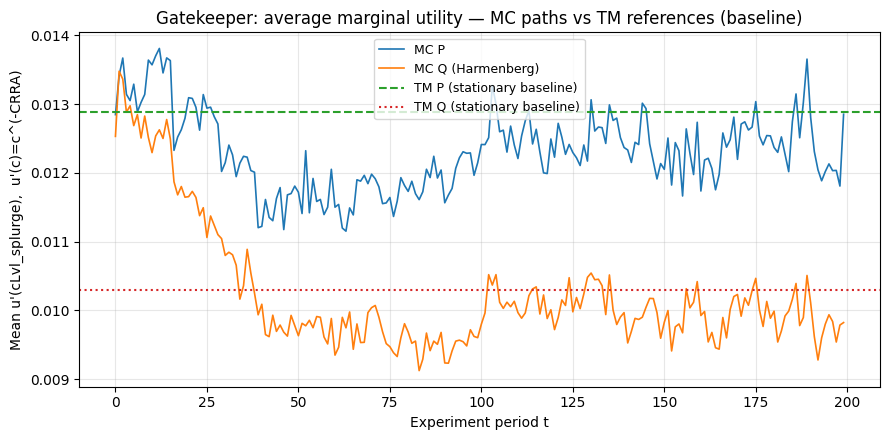

In [6]:
# Last output: time series of cross-sectional mean marginal utility (four methods)
%matplotlib inline
import matplotlib.pyplot as plt

t_mu = out["mu_time_series_t"]
y_p = out["mu_time_series_mc_p"]
y_q = out["mu_time_series_mc_q"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_mu, y_p, label="MC P", color="C0", lw=1.2)
ax.plot(t_mu, y_q, label="MC Q (Harmenberg)", color="C1", lw=1.2)
ax.axhline(
    out["mean_mu_tm_p"],
    color="C2",
    ls="--",
    lw=1.5,
    label="TM P (stationary baseline)",
)
ax.axhline(
    out["mean_mu_tm_q"],
    color="C3",
    ls=":",
    lw=1.5,
    label="TM Q (stationary baseline)",
)
ax.set_xlabel("Experiment period t")
ax.set_ylabel("Mean u'(cLvl_splurge),  u'(c)=c^(-CRRA)")
ax.set_title(
    "Gatekeeper: average marginal utility — MC paths vs TM references (baseline)"
)
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

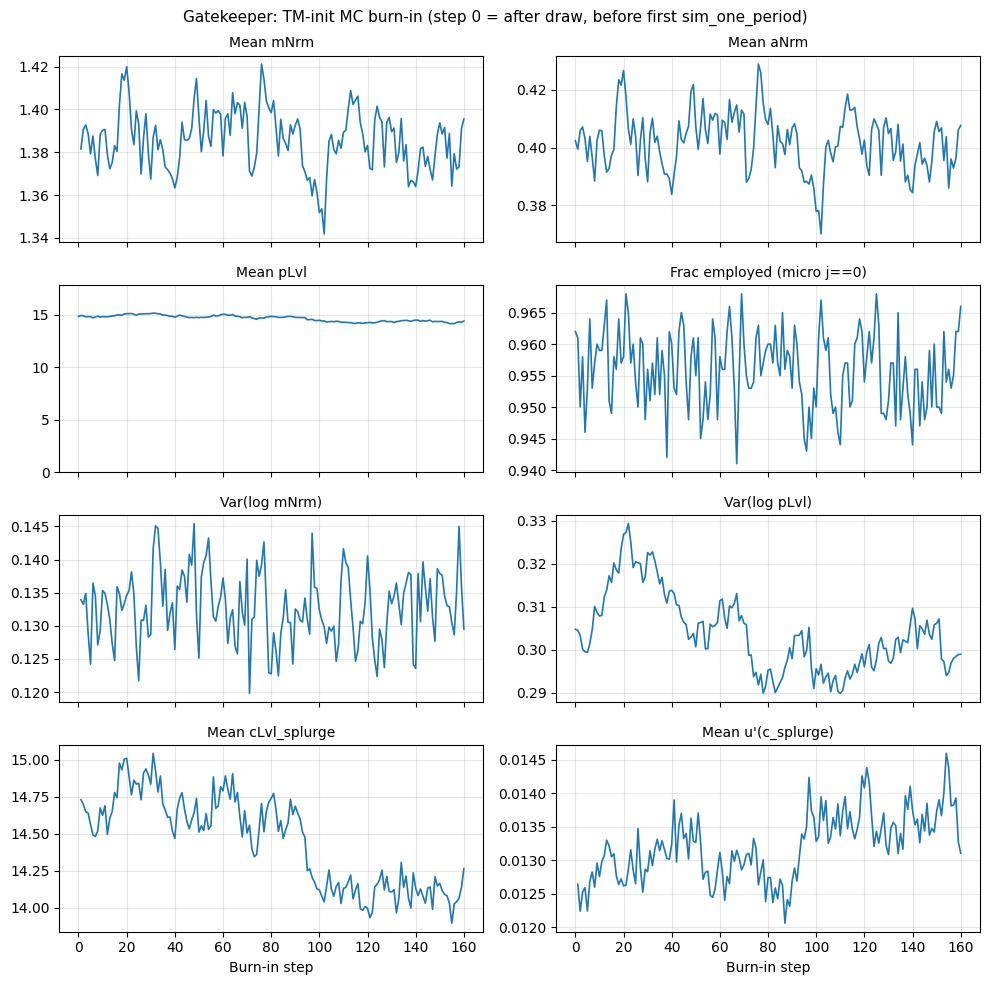


First 10 burn-in steps: mean(pLvl)
  step   0: 14.8588
  step   1: 14.9578
  step   2: 14.9088
  step   3: 14.8297
  step   4: 14.8395
  step   5: 14.8380
  step   6: 14.7280
  step   7: 14.8127
  step   8: 14.8755
  step   9: 14.7938


In [7]:
# Last output: burn-in dynamics (TM draw + sim_one_period inner steps)
%matplotlib inline
import matplotlib.pyplot as plt

bt = out.get("burnin_trace")
if bt is None:
    print(
        "No burn-in trace (use_burnin=False or record_burnin_trace=False); skip figure."
    )
else:
    x = bt["step"]
    fig, axes = plt.subplots(4, 2, figsize=(10, 10), sharex=True)
    axes = axes.ravel()

    def _plot(ax, y, title, ylim=None):
        ax.plot(x, y, lw=1.2)
        ax.set_title(title, fontsize=10)
        ax.grid(True, alpha=0.3)
        if ylim is not None:
            ax.set_ylim(ylim)

    # Set pLvl y-axis from 0 to 120% of initial value
    pLvl_init = bt["mean_pLvl"][0]
    pLvl_ylim = (0, pLvl_init * 1.2)

    _plot(axes[0], bt["mean_mNrm"], "Mean mNrm")
    _plot(axes[1], bt["mean_aNrm"], "Mean aNrm")
    _plot(axes[2], bt["mean_pLvl"], "Mean pLvl", ylim=pLvl_ylim)
    _plot(axes[3], bt["frac_employed"], "Frac employed (micro j==0)")
    _plot(axes[4], bt["var_log_mNrm"], "Var(log mNrm)")
    _plot(axes[5], bt["var_log_pLvl"], "Var(log pLvl)")
    _plot(axes[6], bt["mean_cLvl_splurge"], "Mean cLvl_splurge")
    _plot(axes[7], bt["mean_mu"], "Mean u'(c_splurge)")

    fig.suptitle(
        "Gatekeeper: TM-init MC burn-in (step 0 = after draw, before first sim_one_period)",
        fontsize=11,
    )
    axes[-2].set_xlabel("Burn-in step")
    axes[-1].set_xlabel("Burn-in step")
    fig.tight_layout()
    plt.show()

    # Print first 10 values of mean_pLvl for diagnosis
    pLvl_vals = bt["mean_pLvl"]
    print("\nFirst 10 burn-in steps: mean(pLvl)")
    for i in range(min(10, len(pLvl_vals))):
        print(f"  step {bt['step'][i]:3d}: {pLvl_vals[i]:.4f}")


Running WITHOUT variance_reduction...
CRRA =  2.0
Rfree_base =  [1.01]
Rspell =  6
Splurge =  0.24608006794675005
beta/nablas =  [[0.7367769115195405, 0.29643835347906666, 6.15172479984486, 0.9978747213167333], [0.9247767556186197, 0.07789834940029464, 4.191098588731672, 0.9850958403144185], [0.9821148354049904, 0.014677315032771067, 6.277995962148845, 0.9981263583982957]]
TaxCutAdjFactor =  1
CheckAdjFactor =  1
IncUnempNoBenefits =  0.5
IncUnemp =  0.7
ADelasticity =  0.3
EducationGroup:  0 , betaDistr : [0.7368]
EducationGroup:  1 , betaDistr : [0.9248]
EducationGroup:  2 , betaDistr : [0.9821]


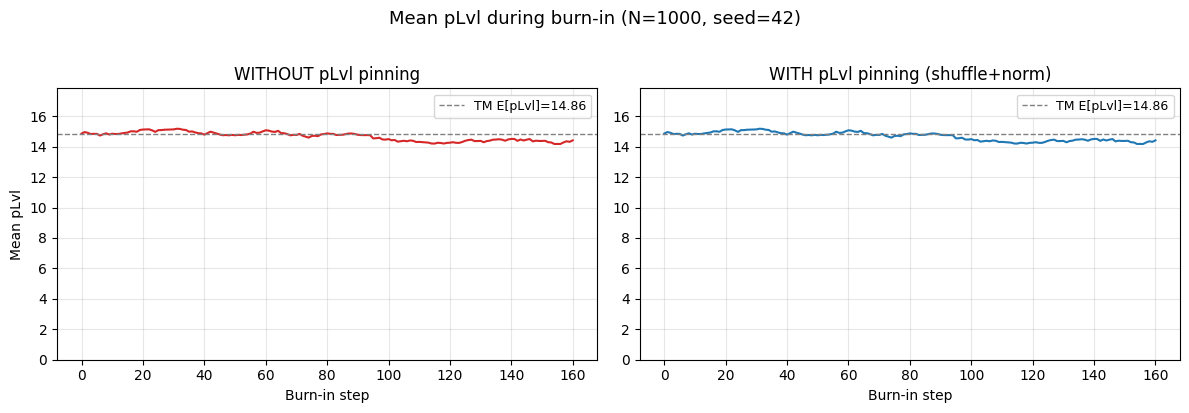


Step 0 (after TM draw, before sim_one_period):
  Without pinning: 14.8588
  With pinning:    14.8588
  TM analytical:   14.8588
  Init error without pinning: +0.00%
  Init error with pinning:    +0.00%

Step 10:
  Without pinning: 14.8478
  With pinning:    14.8478


In [8]:
# Side-by-side comparison: with vs without pLvl pinning
from verify_four_methods_agreement import compare_four_methods

# Run WITHOUT variance_reduction (no pinning)
print('Running WITHOUT variance_reduction...')
out_nopinning = compare_four_methods(
    verbose=False,
    **{**GATEKEEPER_PARAMS, 'variance_reduction': False, 'record_burnin_trace': True,
       'check_mu': False, 'diagnose_init': False}
)
bt_no = out_nopinning.get('burnin_trace')
bt_yes = out.get('burnin_trace')  # from the main run (with pinning)

if bt_no is not None and bt_yes is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Shared y-axis: 0 to 120% of the pinned initial value
    p0 = bt_yes['mean_pLvl'][0]
    ylim = (0, p0 * 1.2)

    ax = axes[0]
    ax.plot(bt_no['step'], bt_no['mean_pLvl'], lw=1.5, color='C3')
    ax.axhline(p0, ls='--', color='gray', lw=1, label=f'TM E[pLvl]={p0:.2f}')
    ax.set_title('WITHOUT pLvl pinning', fontsize=12)
    ax.set_xlabel('Burn-in step')
    ax.set_ylabel('Mean pLvl')
    ax.set_ylim(ylim)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(bt_yes['step'], bt_yes['mean_pLvl'], lw=1.5, color='C0')
    ax.axhline(p0, ls='--', color='gray', lw=1, label=f'TM E[pLvl]={p0:.2f}')
    ax.set_title('WITH pLvl pinning (shuffle+norm)', fontsize=12)
    ax.set_xlabel('Burn-in step')
    ax.set_ylim(ylim)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    fig.suptitle(
        f'Mean pLvl during burn-in (N={GATEKEEPER_PARAMS["agents"]}, seed={GATEKEEPER_PARAMS["seed"]})',
        fontsize=13, y=1.02
    )
    fig.tight_layout()
    plt.show()

    # Print comparison
    print(f'\nStep 0 (after TM draw, before sim_one_period):')
    print(f'  Without pinning: {bt_no["mean_pLvl"][0]:.4f}')
    print(f'  With pinning:    {bt_yes["mean_pLvl"][0]:.4f}')
    print(f'  TM analytical:   {p0:.4f}')
    print(f'  Init error without pinning: {(bt_no["mean_pLvl"][0]/p0 - 1)*100:+.2f}%')
    print(f'  Init error with pinning:    {(bt_yes["mean_pLvl"][0]/p0 - 1)*100:+.2f}%')
    print(f'\nStep 10:')
    i10 = min(10, len(bt_no['step'])-1)
    print(f'  Without pinning: {bt_no["mean_pLvl"][i10]:.4f}')
    print(f'  With pinning:    {bt_yes["mean_pLvl"][i10]:.4f}')
else:
    print('Burn-in trace not available for comparison.')
